# Motivation: Network Security

By now, you have explored how to peform a simple analysis of a network packet capture. In this hands-on activity, you will explore two network packet captures: (1) A network packet trace containing a network scan. (2) A regular network packet trace with no abnormal or malicious activity.

We will not (yet) apply machine learning models to this data. The purpose of this assignment is to give you more experience manipulating network data, but also to think about the types of features in network security incidents that might lend themselves to automated detection of anomalies and attacks.

## Learning Objectives

By the end of this hands-on assignment, you should learn the following:

1. Gain more experience with network traffic traces.
2. Explore the properties of a "normal" and "abnormal" network traffic trace.
3. Think about how these properties differ, and how you might design an automated detection.

After these steps, we'll be ready to start thinking about the role of machine learning in solving some of these problems.

## Background: Log4j Vulnerability

The Log4j vulnerability is a vulnerability to Apache Web servers that resulted in the ability to execute remote code on the victim computer. After a successful attack, an attacker may also be able to steal data from the victim computer. 

One of the precursors to many remote exploits is a process called *scanning*, whereby an attacker sends traffic to remote destinations on the Internet in an attempt to find vulnerable machines to attack. 

Because the Log4j vulnerability is a remote web server vulnerability, the attack in fact looks like a sequence of web requests, although the sequence will certainly look different than that of a normal web trace.

In addition to the Log4j web trace, I took a short packet trace of web traffic from my home. In this hands-on activity, we'll compare the two and reflect on the differences.

## Part 1: Load and Explore the Traffic Traces

Load the two traffic traces, `log4j.csv.gz` and `http.csv.gz`, available in the course Github repository.

In [22]:
import pandas as pd
ldf = pd.read_csv("data/log4j.csv.gz")
hdf = pd.read_csv("data/http.csv.gz")

### Sanity Checks

Take a quick look at the data to make sure it loaded correctly.

In [23]:
ldf.head(3)

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,2021-12-15 15:35:00.237882,zl-lax-us-gp3-wk106b.internet-census.org,91.247.71.198.host.secureserver.net,TCP,74,57468 > 80 [SYN] Seq=0 Win=29200 Len=0 MSS=146...
1,2,2021-12-15 15:35:00.237939,91.247.71.198.host.secureserver.net,zl-lax-us-gp3-wk106b.internet-census.org,TCP,74,"80 > 57468 [SYN, ACK] Seq=0 Ack=1 Win=65160 Le..."
2,3,2021-12-15 15:35:00.249425,zl-lax-us-gp3-wk106b.internet-census.org,91.247.71.198.host.secureserver.net,TCP,66,57468 > 80 [ACK] Seq=1 Ack=1 Win=29312 Len=0 T...


In [24]:
hdf.head(3)

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,2022-09-29 20:24:42.043476,192.168.1.58,43.224.186.35.bc.googleusercontent.com,TLSv1.2,109,Application Data
1,2,2022-09-29 20:24:42.056745,43.224.186.35.bc.googleusercontent.com,192.168.1.58,TCP,66,443 > 57256 [ACK] Seq=1 Ack=44 Win=270 Len=0 T...
2,3,2022-09-29 20:24:42.076282,43.224.186.35.bc.googleusercontent.com,192.168.1.58,TLSv1.2,106,Application Data


### Basic Exploration

Explore a few things about the traces to better understand what the data contains:
* How many packets is in each trace?
* What is the duration of each trace?

Sanity checks on the data you load are often some of the more important steps in data acquisition and quality checking. Without good quality data, ... What other "sanity checks can you think of?

In [25]:
ldf_packet_num = len(ldf)
hdf_packet_num = len(hdf)
ldf_duration = pd.to_datetime(ldf['Time']).iloc[-1] - pd.to_datetime(ldf['Time']).iloc[0]
hdf_duration = pd.to_datetime(hdf['Time']).iloc[-1] - pd.to_datetime(hdf['Time']).iloc[0]
print("Number of packets in ldf: ", ldf_packet_num)
print("Number of packets in hdf: ", hdf_packet_num)
print("ldf duration: ", ldf_duration)
print("hdf duration: ", hdf_duration)

Number of packets in ldf:  80843
Number of packets in hdf:  24798
ldf duration:  4 days 23:06:44.643896
hdf duration:  0 days 00:00:48.918264


### Feature Exploration

You may also wish to explore some other more basic statistics in the trace, such as the following:
* Number of unique destinations
* Distribution of packet length
* Packets of different protocol types

Plot and/or summarize some of these features below.

#### Setup: one identity per trace

We give each trace a fixed name and color and reuse them in every figure below, so the
same trace always looks the same way, and we pin both inter-arrival plots to the same
x-axis range so they can be read side by side.

In [26]:
import arrow
import numpy as np
import matplotlib.pyplot as plt

# Fixed identity per trace: the color always follows the trace, never the chart.
TRACES = {'Log4j scan': (ldf, '#2a78d6'),
          'Normal HTTP': (hdf, '#eb6834')}

INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e5e5e2'

# Shared range for the two IAT plots below, so their shapes are directly comparable.
IAT_XLIM = (1e-3, 2e5)

def tidy(ax, hide=('top', 'right')):
    """Recessive axes: keep the data, drop the box."""
    for side in hide:
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)
    return ax

def ms_label(v):
    """A duration in milliseconds, written the way a person would say it."""
    if v >= 1000:
        return f'{v / 1000:,.3g}s'
    return f'{v:,.3g}ms'

def ms_ticks(ax):
    """Label a log axis with plain durations instead of powers of ten."""
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: ms_label(v)))
    return ax

#### Distribution of packet inter-arrival times

How long passes between one packet and the next? We plot the CDF on a log x-axis, because
the inter-arrival times span eight orders of magnitude - from microseconds to minutes.

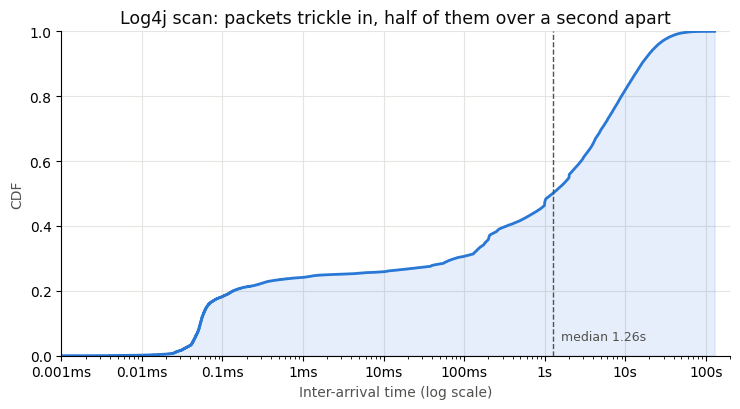

In [27]:
ldf['timestamp'] = ldf.apply(lambda row: arrow.get(row['Time']).timestamp(), axis=1)
ldf['iat'] = ldf['timestamp'].diff() * 1000

iat = ldf['iat'].dropna().sort_values()
cdf = np.arange(1, len(iat) + 1) / len(iat)
median = iat.median()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(iat, cdf, lw=2, color='#2a78d6', label='Log4j scan')
ax.fill_between(iat, cdf, color='#2a78d6', alpha=0.12)

# Call out the median rather than labelling every point.
ax.axvline(median, color=MUTED, lw=1, ls='--')
ax.annotate(f'median {ms_label(median)}', xy=(median, 0.05), xytext=(6, 0),
            textcoords='offset points', color=MUTED, fontsize=9)

ax.set_xscale('log')
ax.set_xlim(*IAT_XLIM)
ax.set_ylim(0, 1)
ax.set_xlabel('Inter-arrival time (log scale)', color=MUTED)
ax.set_ylabel('CDF', color=MUTED)
ax.set_title('Log4j scan: packets trickle in, half of them over a second apart', fontsize=12.5, color=INK)
ax.grid(color=GRID, lw=0.8)
tidy(ax)
ms_ticks(ax)
fig.tight_layout()
plt.show()

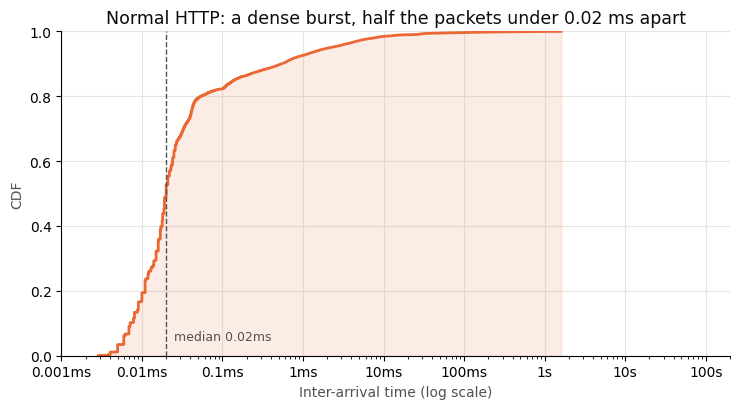

In [28]:
hdf['timestamp'] = hdf.apply(lambda row: arrow.get(row['Time']).timestamp(), axis=1)
hdf['iat'] = hdf['timestamp'].diff() * 1000

iat = hdf['iat'].dropna().sort_values()
cdf = np.arange(1, len(iat) + 1) / len(iat)
median = iat.median()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(iat, cdf, lw=2, color='#eb6834', label='Normal HTTP')
ax.fill_between(iat, cdf, color='#eb6834', alpha=0.12)

# Call out the median rather than labelling every point.
ax.axvline(median, color=MUTED, lw=1, ls='--')
ax.annotate(f'median {ms_label(median)}', xy=(median, 0.05), xytext=(6, 0),
            textcoords='offset points', color=MUTED, fontsize=9)

ax.set_xscale('log')
ax.set_xlim(*IAT_XLIM)
ax.set_ylim(0, 1)
ax.set_xlabel('Inter-arrival time (log scale)', color=MUTED)
ax.set_ylabel('CDF', color=MUTED)
ax.set_title('Normal HTTP: a dense burst, half the packets under 0.02 ms apart', fontsize=12.5, color=INK)
ax.grid(color=GRID, lw=0.8)
tidy(ax)
ms_ticks(ax)
fig.tight_layout()
plt.show()

Note the x-axis is identical in both plots. The normal HTTP capture is packed against the
left edge - it is a short, dense burst of back-to-back packets belonging to a few active
connections. The Log4j curve is shifted roughly five orders of magnitude to the right:
scan traffic arrives as isolated probes separated by long idle gaps.

Be careful with this one as a feature, though. The *shape* reflects real behavior, but the
absolute spacing also depends on where the capture was taken and how busy the link was.

#### Number of unique destinations

How many distinct hosts does each trace talk to, and how much traffic does it exchange
with each one?

In [29]:
def duration_s(df):
    t = pd.to_datetime(df['Time'])
    return (t.iloc[-1] - t.iloc[0]).total_seconds()

summary = pd.DataFrame({
    name: {
        'Packets': len(df),
        'Unique sources': df['Source'].nunique(),
        'Unique destinations': df['Destination'].nunique(),
        'Distinct protocols': df['Protocol'].nunique(),
        'Duration (s)': round(duration_s(df), 1),
        'Destinations per minute': round(df['Destination'].nunique() / (duration_s(df) / 60), 2),
        'Packets per destination': round(len(df) / df['Destination'].nunique(), 1),
    }
    for name, (df, _) in TRACES.items()
})
summary

,Log4j scan,Normal HTTP
Packets,80843.0,24798.00
Unique sources,7188.0,104.00
Unique destinations,2179.0,104.00
Distinct protocols,54.0,6.00
Duration (s),428804.6,48.90
Destinations per minute,0.3,127.56
Packets per destination,37.1,238.40


Two of these rows behave very differently as features:

* **Destinations per minute** depends entirely on how long each capture happened to run.
  The Log4j capture spans about five days and the HTTP capture about 49 seconds, so this
  row says more about the collection than about the behavior.
* **Packets per destination** is *scale-free* - it does not care how long we captured.
  A scanner sends a handful of probes to each of many hosts and moves on; a browser opens
  a few connections and exchanges many packets with each one.

#### Distribution of packet length

First as two histograms on a shared axis (the shape of each distribution), then as a
single CDF (the two distributions directly against each other).

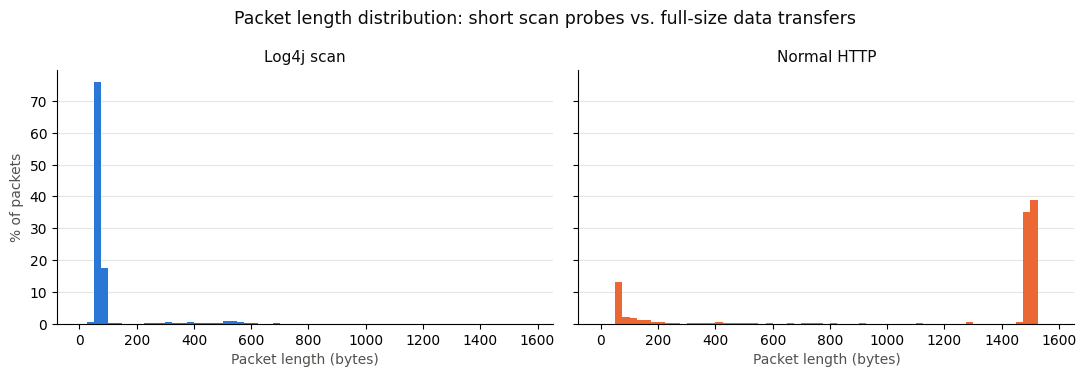

In [30]:
bins = np.arange(0, 1600, 25)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True, sharey=True)
for ax, (name, (df, color)) in zip(axes, TRACES.items()):
    # Weight each packet so the bars read as "% of this trace", making the panels comparable.
    ax.hist(df['Length'].clip(upper=1550), bins=bins, color=color,
            weights=np.full(len(df), 100 / len(df)))
    ax.set_title(name, fontsize=11, color=INK)
    ax.set_xlabel('Packet length (bytes)', color=MUTED)
    ax.grid(axis='y', color=GRID, lw=0.8)
    tidy(ax)

axes[0].set_ylabel('% of packets', color=MUTED)
fig.suptitle('Packet length distribution: short scan probes vs. full-size data transfers',
             fontsize=12.5, color=INK)
fig.tight_layout()
plt.show()

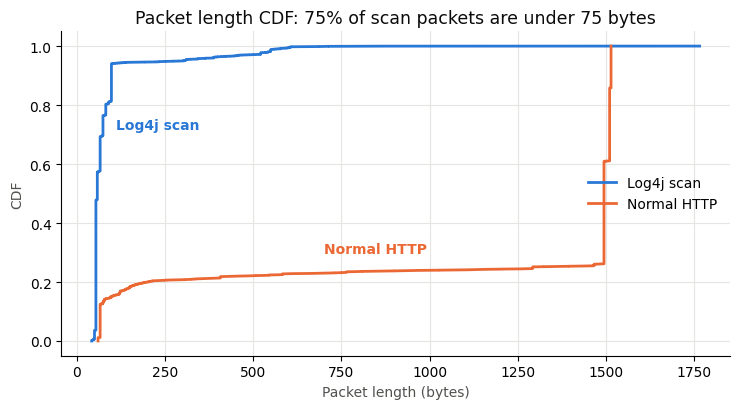

In [31]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, (df, color) in TRACES.items():
    x = np.sort(df['Length'].values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, lw=2, color=color, label=name)

# Direct labels so identity never rests on color alone.
ax.annotate('Log4j scan', xy=(110, 0.72), color='#2a78d6', fontsize=10, fontweight='bold')
ax.annotate('Normal HTTP', xy=(700, 0.30), color='#eb6834', fontsize=10, fontweight='bold')

ax.set_xlabel('Packet length (bytes)', color=MUTED)
ax.set_ylabel('CDF', color=MUTED)
ax.set_title('Packet length CDF: 75% of scan packets are under 75 bytes',
             fontsize=12.5, color=INK)
ax.grid(color=GRID, lw=0.8)
tidy(ax)
ax.legend(frameon=False, loc='center right')
fig.tight_layout()
plt.show()

The Log4j trace is almost entirely small packets - TCP handshakes and ICMP probes that
carry no payload. The HTTP trace is strongly bimodal: small control packets plus a large
mass at ~1500 bytes, the Ethernet MTU, which is what bulk data transfer looks like.

#### Packets of different protocol types

The two traces differ by a factor of three in packet count, so we compare **shares** of
each trace rather than raw counts. Protocols outside each trace's top five are folded
into `Other`.

In [32]:
shares = {name: df['Protocol'].value_counts(normalize=True) * 100
          for name, (df, _) in TRACES.items()}

keep = set()
for s in shares.values():
    keep |= set(s.head(5).index)
order = sorted(keep, key=lambda p: -max(s.get(p, 0) for s in shares.values()))

protocols = pd.DataFrame({name: [s.get(p, 0) for p in order] for name, s in shares.items()},
                         index=order)
protocols.loc['Other'] = [100 - protocols[name].sum() for name in protocols.columns]
protocols.round(2)

,Log4j scan,Normal HTTP
TCP,72.09,80.68
ICMP,19.40,0.00
TLSv1.2,0.00,16.27
HTTP,4.78,0.04
QUIC,0.02,1.85
UDP,1.37,0.00
DNS,0.20,1.14
NTP,0.87,0.00
Other,1.26,0.02


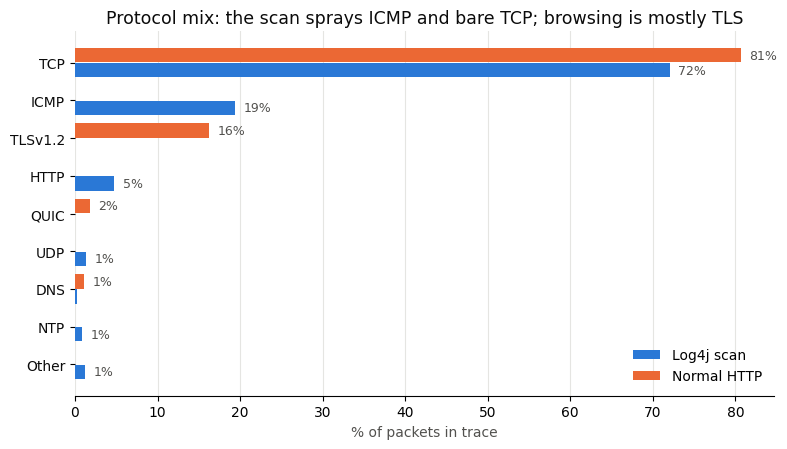

In [33]:
y = np.arange(len(protocols))
height = 0.38

fig, ax = plt.subplots(figsize=(8, 4.6))
for i, (name, (df, color)) in enumerate(TRACES.items()):
    offset = (0.5 - i) * (height + 0.02)   # 2% surface gap between adjacent bars
    ax.barh(y + offset, protocols[name], height=height, color=color, label=name)
    for yi, v in zip(y + offset, protocols[name]):
        if v > 0.5:
            ax.text(v + 1, yi, f'{v:.0f}%', va='center', fontsize=9, color=MUTED)

ax.set_yticks(y)
ax.set_yticklabels(protocols.index, color=INK)
ax.invert_yaxis()
ax.set_xlabel('% of packets in trace', color=MUTED)
ax.set_title('Protocol mix: the scan sprays ICMP and bare TCP; browsing is mostly TLS',
             fontsize=12.5, color=INK)
ax.grid(axis='x', color=GRID, lw=0.8)
tidy(ax, hide=('top', 'right', 'left'))
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
plt.show()

#### Summary of what the features show

| Feature | Log4j scan | Normal HTTP |
| --- | --- | --- |
| Unique destinations | many, each contacted briefly | few, each contacted heavily |
| Packet length | almost all small (median 58 bytes) | bimodal, large mass at the ~1500-byte MTU |
| Protocol mix | ICMP + bare TCP, long tail of 54 protocols | TCP + TLS, only 6 protocols |

The scan never completes much useful work with any single host: it probes, gets no reply
or a reset, and moves on. Normal browsing does the opposite. Keep this in mind for the
question below - some of these differences reflect genuinely different *behavior*, while
others (how long we captured, which addresses appear) are artifacts of these two
particular captures.

### Thought Question

In general, as we design classification or prediction algorithms, we seek features (and representations of features) that distinguish normal activity from malicious activity. It's important that the features are characteristic of fundamental differences in the two behaviors, rather than simply characteristics of the dataset.

An example of an inappropriate feature, for example, would be the time of day. These two traces were gathered at different dates and times, but normal traffic (and Log4j scans) can occur at any date or time. Thus, time would not make a robust feature. 

Can you think of other features that might separate the two datasets but not make good features?

Which features do you think would make good features? Why or why not?